In [5]:
import sys
import os
sys.path.append(os.path.abspath(".."))
from training.lr import get_lr_scheduler
from collections import namedtuple


CFG = namedtuple('cfg', ['type', 'low_lr', 'warmup', 'warmup_steps', 'gamma'], defaults=[None] * 5)

cfgs = [
    CFG(type='cosine', low_lr=0.000005, warmup=False, warmup_steps=0.0),
    CFG(type='cosine', low_lr=0.000005, warmup=True, warmup_steps=0.1),
    CFG(type='constant', low_lr=0.000005, warmup=False, warmup_steps=0.0),
    CFG(type='exponential', low_lr=0.000005, warmup=False, warmup_steps=0.0, gamma=0.99)
]

100


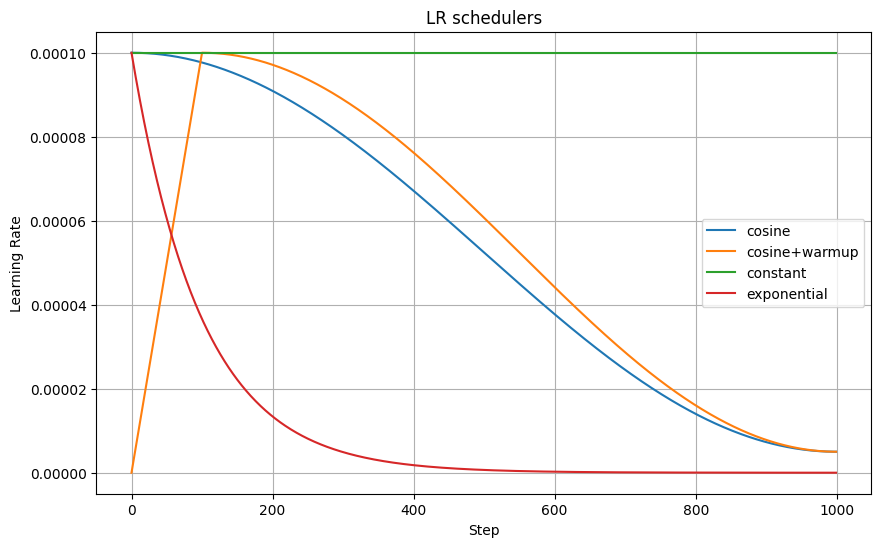

In [6]:
import matplotlib.pyplot as plt
from torch.optim import SGD
import torch

model = torch.nn.Linear(10, 1)
lr = 1e-4
steps = 1000

plt.figure(figsize=(10,6))
for cfg in cfgs:
    optimizer = SGD(model.parameters(), lr=lr)
    scheduler = get_lr_scheduler(optimizer, cfg, steps)
    
    lrs = []
    for step in range(steps):
        lrs.append(optimizer.param_groups[0]['lr'])
        scheduler.step()

    label = f"{cfg.type}" + (f"+warmup" if cfg.warmup else "")
    plt.plot(range(steps), lrs, label=label)


plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.title("LR schedulers")
plt.legend()
plt.grid(True)
plt.show()
